## Installations

In [1]:
import paddle
print(paddle.__version__)

C:\ProgramData\anaconda3\envs\paddleocr_gpu\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


3.2.0


In [2]:
import paddleocr
print("paddleocr:", paddleocr.__version__)

C:\ProgramData\anaconda3\envs\paddleocr_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


paddleocr: 3.4.1


In [4]:
import paddle

print("PaddlePaddle:", paddle.__version__)
print("CUDA available:", paddle.is_compiled_with_cuda())
print("GPU count:", paddle.device.cuda.device_count())

if paddle.device.cuda.device_count() > 0:
    print("Current device:", paddle.device.get_device())

PaddlePaddle: 3.2.0
CUDA available: True
GPU count: 1
Current device: gpu:0


In [5]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR
from PIL import Image
from jiwer import wer, cer

In [6]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang="de",
    device="gpu:0",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

print("PaddleOCR loaded successfully")

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\latin_PP-OCRv5_mobile_rec`.


PaddleOCR loaded successfully


## Download Dataset


In [11]:
import os

data_dir = "../test_img"

pages = [
    53,
    78,
    114,
    490
]

for p in pages:
    image_path = os.path.join(data_dir, f"{p}.jpg")
    print(image_path, ":", os.path.exists(image_path))

../test_img\53.jpg : True
../test_img\78.jpg : True
../test_img\114.jpg : True
../test_img\490.jpg : True


## Draw Bounding Box

In [10]:
def draw_bounding_boxes(image_path, min_conf=0.0, save_path=None):
    image = cv2.imread(image_path)

    results = ocr.predict(image_path)

    img_boxes = image.copy()

    if results:
        result = results[0]

        boxes = result["dt_polys"]
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for bbox, text, conf in zip(boxes, texts, scores):
            if text.strip() != "" and conf >= min_conf:
                pts = np.array(bbox, dtype=np.int32)

                cv2.polylines(
                    img_boxes,
                    [pts],
                    isClosed=True,
                    color=(0, 255, 0),
                    thickness=1
                )

    #phto save
    if save_path is not None:
        cv2.imwrite(save_path, img_boxes)
        print(f"Bounding box image saved: {save_path}")

    img_boxes = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 12))
    plt.imshow(img_boxes)
    plt.title(f"Detected Text Boxes: {image_path}")
    plt.axis("off")
    plt.show()

## Camera Captured Image to OCR
  

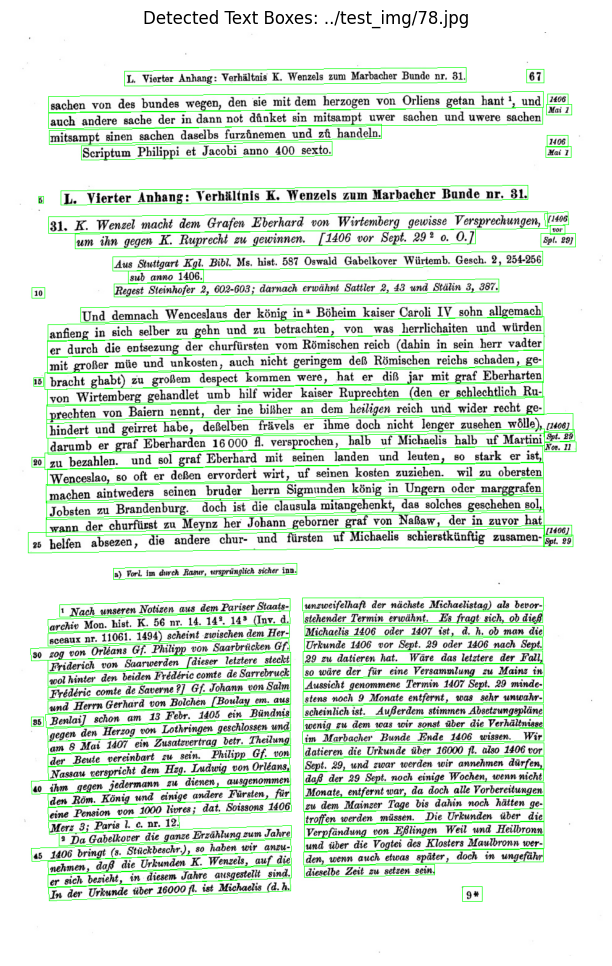

In [12]:
draw_bounding_boxes("../test_img/78.jpg", min_conf=0.0)

In [13]:
def extract_text_paddleocr(image_path, min_conf=0.0):
    results = ocr.predict(image_path)

    extracted_lines = []

    if results:
        result = results[0]

        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, conf in zip(texts, scores):
            if str(text).strip() != "" and conf >= min_conf:
                extracted_lines.append(text)

    return "\n".join(extracted_lines)

In [14]:
text = extract_text_paddleocr( "../test_img/78.jpg", min_conf=0.0)
print(text)

L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
67
sachen von des bundes wegen, den sie mit dem herzogen von Orliens getan hant 1, und
1406
Mai 1
auch andere sache der in dann not dünket sin mitsampt uwer sachen und uwere sachen
mitsampt sinen sachen daselbs furzünemen und zû handeln.
1406
Scriptum Philippi et Jacobi anno 400 sexto.
Mai 1
5
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
31. K. Wenzel macht dem Grafen Eberhard von Wirtemberg gewisse Versprechungen,
[1406
vor
um ihn gegen K. Ruprecht zu gewinnen. [1406 vor Sept. 29 2 o. O.]
Spt. 29]
Aus Stuttgart Kgl. Bibl. Ms. hist. 587 Oswald Gabelkover Würtemb. Gesch. 2, 254-256
sub anno 1406.
10
Regest Steinhofer 2, 602-603; darnach erwähnt Sattler 2, 43 und Stälin 3, 387.
Und demnach Wenceslaus der könig inª Böheim kaiser Caroli IV sohn allgemach
anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden
er durch die entsezung der churfürsten vom Römischen reich (dah

In [15]:
import os

output_dir = "Output_improvement/experiment_files"
os.makedirs(output_dir, exist_ok=True)

output_dir_2 = "Output_improvement/experiment_graphs"
os.makedirs(output_dir_2, exist_ok=True)


Page 8_camera
Bounding box image saved: Output_camera/experiment_graphs\8_camera_bounding_boxes.jpg


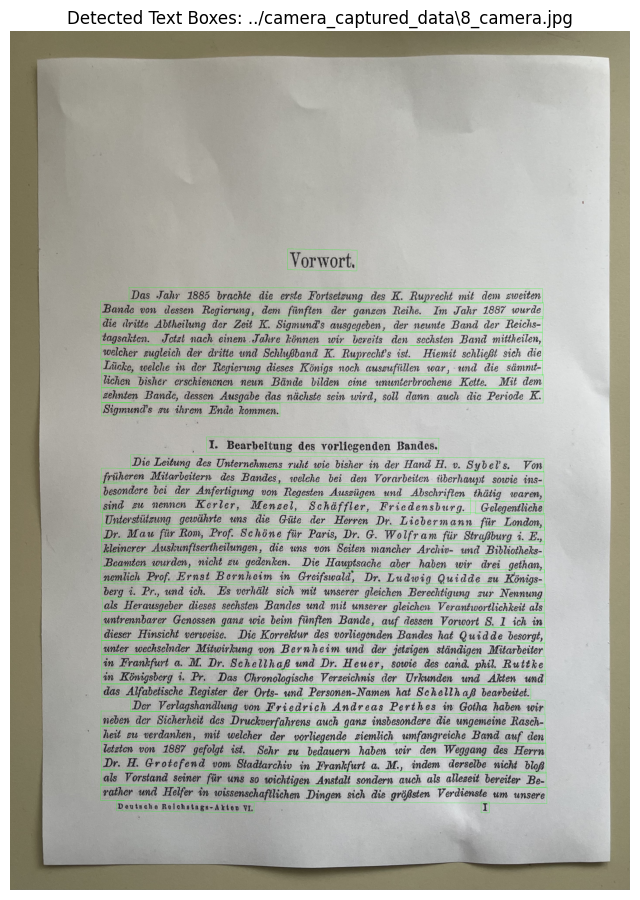

Resized image size (3024x4021) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
Das Jahr 1885 brachte die erste Fortsetzung des K. Ruprecht mit dem zweiten
Bande von dlessen Regierung, dem fiünften der ganzen Reihe. Im Jahr 1887 wurde
die ilritte Abtheilung der Zeit K. Sigmund's ausgegeben, der neunte Band der Reichs-
tagsakten. Jctzt nach cinem Jahre können wir bereits den sechsten Band mittheilen,
welcher zugleich der dritte und Schlußband K. Ruprecht's ist. Hiemit schließt sich die
Lücke, welche in der Regierung dieses Königs noch auseufüllen war, und die sämmt-
lichen bisher crschienenen neun Bände bilden cine ununterbrochene Kette. Mit dem
sehnten Bande, dlessen Ausgabe das nächste sein wird, soll dann auch die Periode K.
Sigmund's au ihrem Ende kommen.
I. Bearbeitung des vorliegenden Bandes.
Die Leitung des Unternehmens ruht wie bisher in der Hand H. v. Sybel's. Von
früheren Mitarbeitern des Bandes, welche bei den Vorarbeiten überhaupt sowie ins-
besondere bei der Anfertigung von Regesten Auszügen und Abschriften thätig waren,
sind zu nennen Kerler,

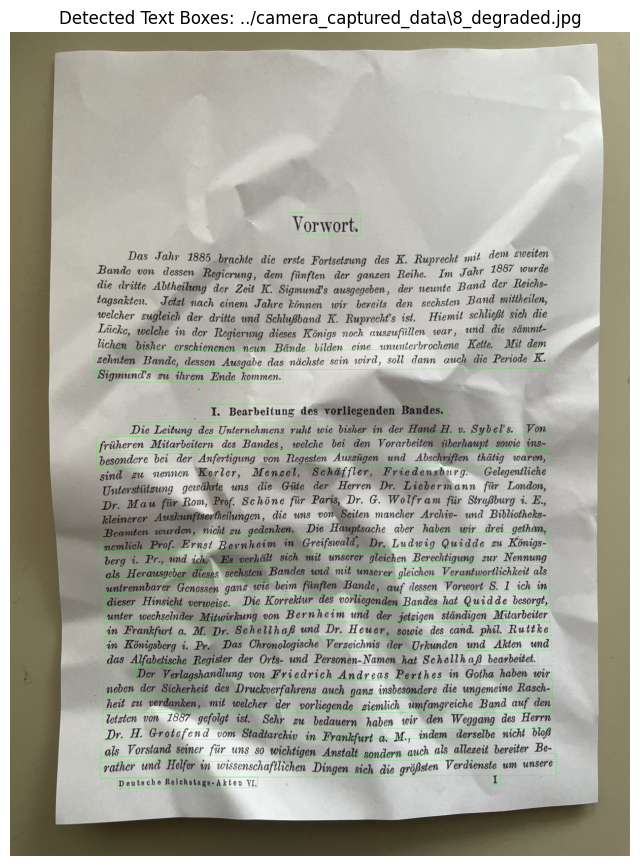

Resized image size (3024x4021) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
zehnten Bande, dessen Ausgabe das nächste scin wird, soll dann auch die Periode K.
Sigmund's zu ihrem Ende kommen.
4
I. Bearbeitung des vorliegenden Bandes.
Die Leitung des Unternehmens ruht wie bisher in der Hand H. v. Sybel's. Von
früheren Mitarbeitern des Bandes, welche bei den Vorarbeiten überhaupt sowie ins-
besondere bei der Anfertigung von Regesten Auszügen und Abschriften thätig waren,
nemlich Prof. Ernst Bernheim in Greifswald, Dr. Ludwig Quidde zu Königs-
berg i. Pr., und ich. Es verhält sich mit unserer gleichen Berechtigung zur Nennung
als Herausgeber dieses sechsten Bandes und mit unserer gleichen Verantwortlichkeit als
untrennbarer Genossen ganz wie beim fünften Bande, auf dessen Vorwort S. I ich in
dieser Hinsicht verweise. Die Korrektur des vorliegenden Bandes hat Quid de besorgt,
unter wechselnder Mitwirkung von Bern heim und der jeteigen ständigen Mitarbeiter
in Frankfurt a. M. Dr. Schellhaß und Dr. Heuer, sowie des cand. phil. Ruttke
in Königsberg i. Pr. Das

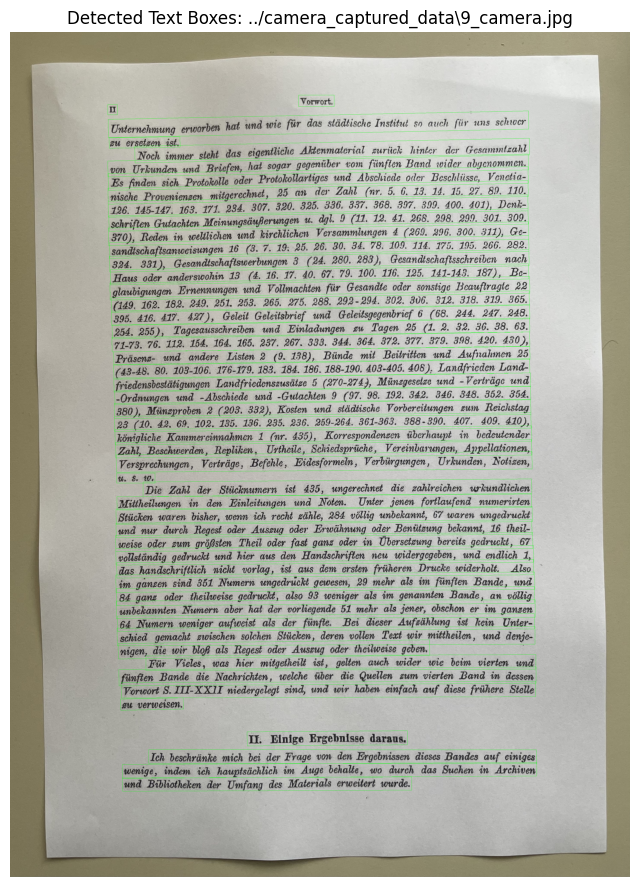

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
Ⅱ
Unternehmung erworben hat und wie für das städtische Institut so auch ſür uns schver
zu ersetzen ist.
Noch immer steht das eigentliche Aktenmaterial zurück hinter der Gesammtzahl
von Urkunden und Briefen, hat sogar gegenüber vom fünften Band wider abyenommen.
Es finden sich Protokolle oder Protokollartiges und Abschiede oder Beschlüssc, Venctia-
nische Proveniensen mitgerechnet, 25 an der Zahl (nr. 5. 6. 13. 14. 15. 27. 89. 110.
126. 145-147. 163. 171. 234. 307. 320. 325. 336. 337. 368. 397. 399. 400. 401), Dcnk-
schriften Gutachten Meinungsäußerungen u. dgl. 9 (11. 12. 41. 268. 298. 299. 301. 309.
370), Reden in wellichen und kirchlichen Versammlungen 4 (269. 296. 300. 311), Ge-
sandtschaftsanweisungen 16 (3. 7. 19: 25. 26. 30. 34. 78. 109. 114. 175. 195. 266. 282.
324. 331), Gesandtschaftswerbungen 3 (24. 280. 283), Gesandtschaftsschreiben nach
Haus oder anderswohin 13 (4. 16. 17. 40. 67. 79. 100. 116. 125. 141-143. 187), Be-
glaubigungen Ernennungen und Vollmachten für Ge

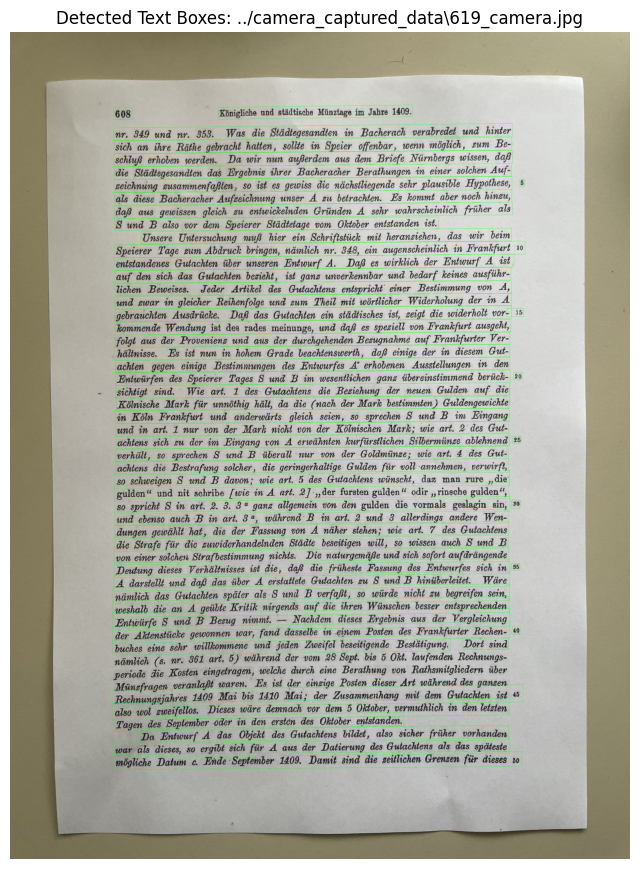

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


608
Königliche und städtische Münztage im Jahre 1409.
nr. 349 und nr. 353. Was die Städtegesandten in Bacherach verabredet und hinter
sich an ihre Räthe gebracht hatten, sollte in Speier offenbar, wenn möglich, zum Be-
schluß erhoben werden. Da wir nun außerdem aus dem Briefe Nürnbergs wissen, daß
die Städtegesandten das Ergebnis ihrer Bachcracher Berathungen in einer solchen Auf-
seichnung zusammenfaßten, so ist es gewiss die nächstliegende sehr plausible Hypothese,
ZD
als diese Bacheracher Aufzeichnung unser A zu betrachten. Es kommt aber noch hineu,
daß aus gewissen gleich zu entwickelnden Gründen A sehr wahrscheinlich früher als
S und B also vor dem Speierer Städtetage vom Oktober entstanden ist.
Unsere Untersuchung muß hier ein Schriftstück mit heranziehen, das wir beim
Speierer Tage zum Abdruck bringen, nämlich nr. 348, ein augenscheinlich in Frankfurt 10
entstandenes Gutachten über unseren Entwurf A. Daß es wirklich der Entwurf A ist.
auf den sich das Gutachten bezieht, ist ganz

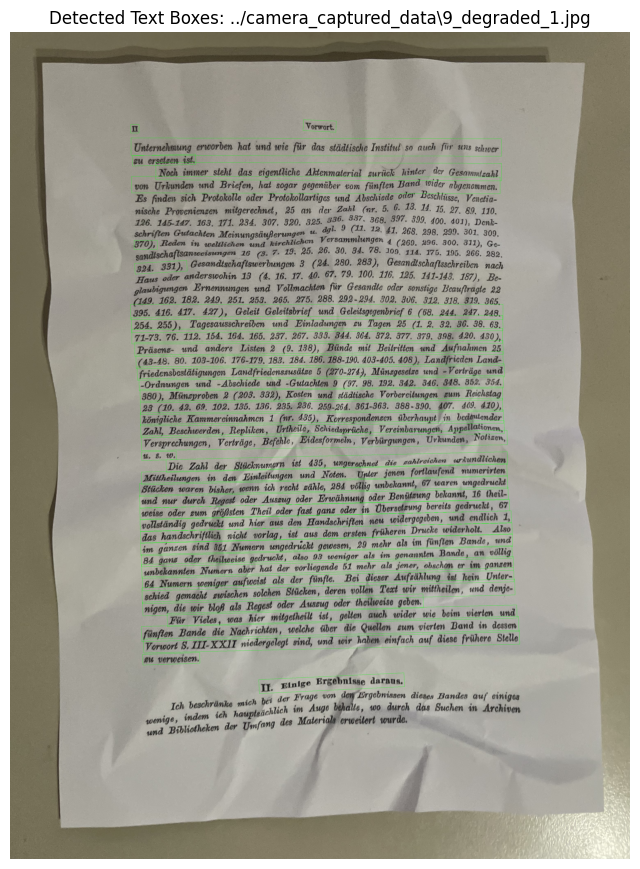

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
Ⅱ
Unternehmung erworben hat und wie für das städtische Institut so auch fr uns schver
eu erseleen ist.
Noch immer steht das eigentliche Aktenmaterial zurück linter der Gesammtzahl
von Urkunden und Briefen, hat sogar gegenüber vom fünften Band wider abyenommen.
370),
324. 331),
395. 416. 417. 427), Geleit Geleitsbrief und Geleitsgegenbrief 6 (68. 244. 247. 248.
254. 255), Tagesausschreiben und Einladungen zu Tagen 25 (1. 2. 32. 36. 38. 63.
7173. 76. 112. 154. 164. 165. 237. 267. 333. 344. 364. 372. 377. 379. 398. 420. 430),
Präsenz- und andere Listen 2 (9. 138), Bünde mit Beitritten und Aufnahmen 25
(43-48. 80. 103-106. 176-179. 183. 184. 186. 188-190. 403-405. 408), Landfricden Land-
ſriedensbostätigungen Landfriodenszusätze 5 (270-274), Münzgeselze und - Verträge und
-Ordnungen und -Abschiede und -Gutachten 9 (97. 98. 192. 342. 346. 348. 352. 354.
380), Münzproben 2 (203. 332), Kosten und städtische Vorbercitungen zum Reichstag
23 (10. 42. 69. 102. 135. 136. 235. 236. 259-264

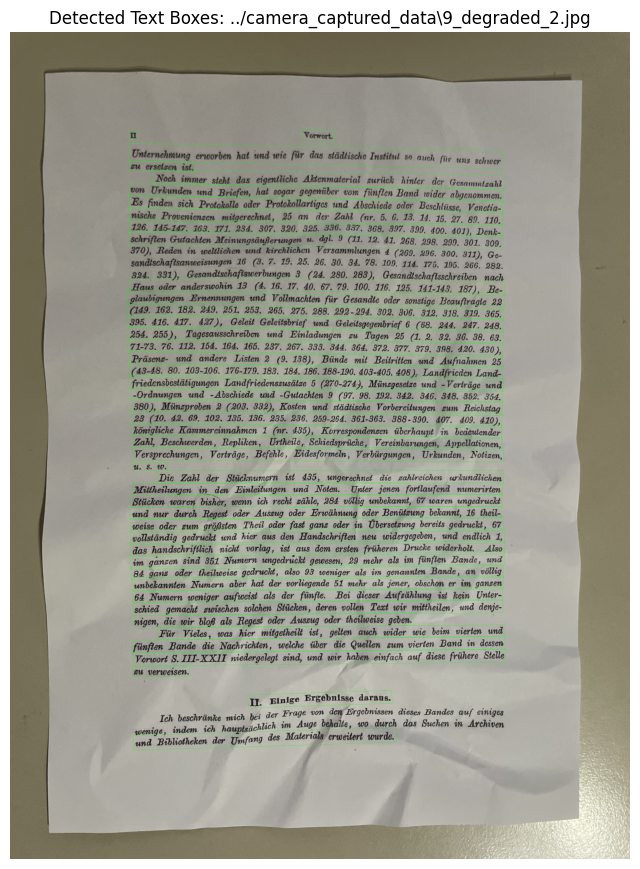

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
ⅡI
Unternehmung ereorben hat und wie fur das städtische Institut so auch für uns schwer
zu ersetzen ist.
Noch immer steht das eigentliche Aktenmaterial zurück hinter der Gesammtzahl
von Urkunden und Briefen, hat sogar gegenüber vom fünften Band wider abyenommen.
Es finden sich Protokolle oder Protokollartiges und Abschiede oder Beschlüsse, Venctia-
nische Provenienzen mitgerechnet, 25 an der Zahl (nr. 5. 6. 13. 14. 15. 27. 89. 110.
126. 145-147. 163. 171. 234. 307. 320. 325. 336. 337. 368. 397. 399. 400. 401), Denk-
schriften Gutachten Meinungsäußerungen u. dgl. 9 (11. 12. 41. 268. 298. 299. 301. 309.
Haus oder anderswohin 13 (4. 16. 17. 40. 67. 79. 100. 116. 125. 141-143. 187), Be-
glaubigungen Ernennungen und Vollmachten für Gesandte oder sonstige Beauftragte 22
(149. 162. 182. 249. 251. 253. 265. 275. 288. 292-294. 302. 306. 312. 318. 319. 365.
395. 416. 417. 427), Geleit Geleitsbrief und Geleitsgegenbrief 6 (68. 244. 247. 248.
254. 255), Tagesausschreiben und Einladungen z

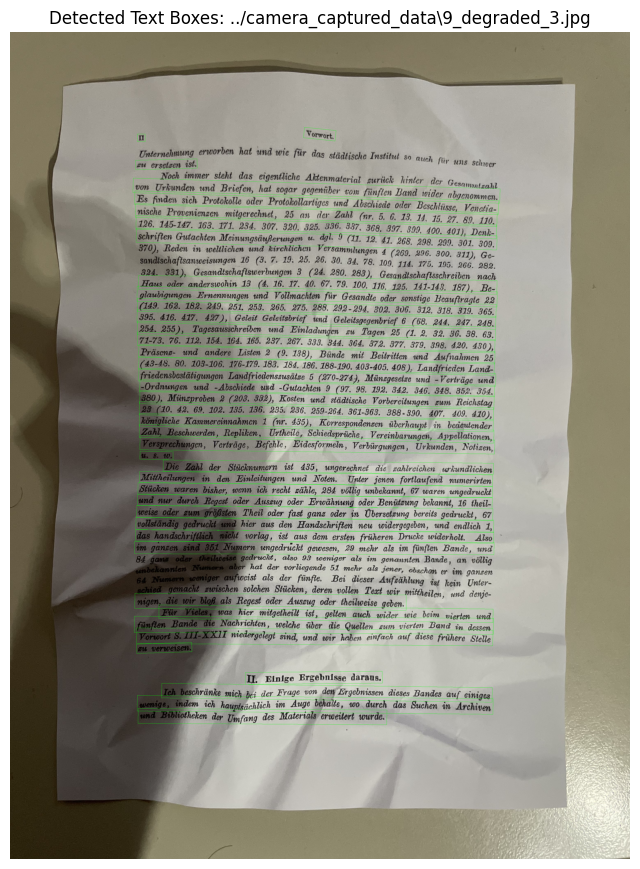

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
II
zu ersetzen ist.
von Urkunden und Briefen, hat sogar gegenüber vom fünften Band wider abyenommen.
Es finden sich Protokolle oder Protokollartiges und Abschiede oder Beschlüsse, Venctia-
nische Provenienzen mitgerechnet, 25 an der Zahl (nr. 5. 6. 13. 14. 15. 27. 89. 110.
126. 145-147. 163. 171. 234. 307. 320. 325. 336. 337. 368. 397. 399. 400. 401), Denk-
schriften Gutachten Meinungsäußerungen u. dgl. 9 (11. 12. 41. 268. 298. 299. 301. 309.
Haus oder anderswohin 13 (4. 16. 17. 40. 67. 79. 100. 116. 125. 141-143. 187), Be-
glaubigungen Ernennungen und Vollmachten für Gesandte oder sonstige Bcauftragte 22
(149. 162. 182. 249. 251. 253. 265. 275. 288. 292-294. 302. 306. 312. 318. 319. 365.
395. 416. 417. 427), Geleit Geleitsbrief und Geleitsgegenbrief 6 (68. 244. 247. 248.
254. 255), Tagesausschreiben und Einladungen zu Tagen 25 (1. 2. 32. 36. 38. 63.
7173. 76. 112. 154. 164. 165. 237. 267. 333. 344. 364. 372. 377. 379. 398. 420. 430),
Präscne- und andere Listen 2 (9. 138), Bün

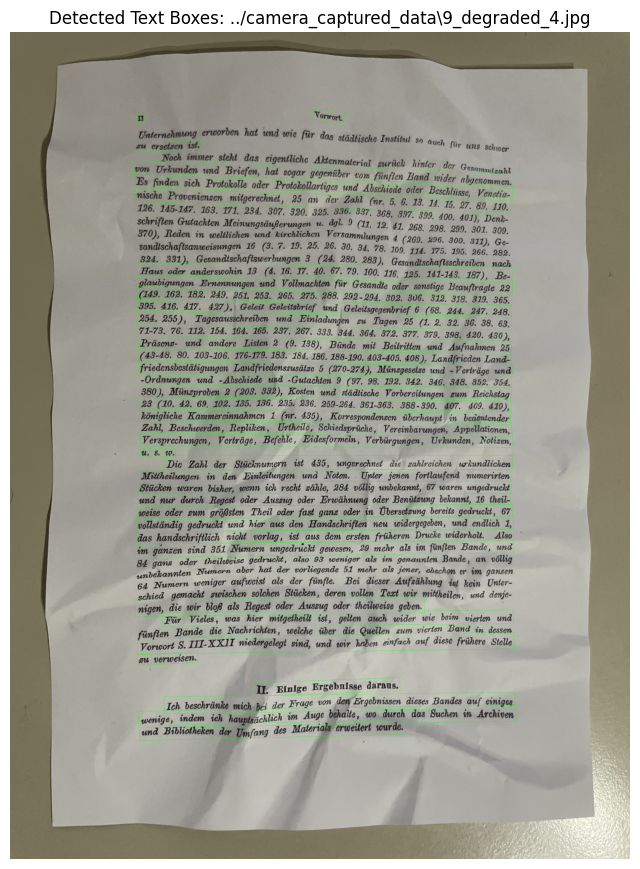

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


Vorwort.
ⅡI
zu ersetzen ist.
von Urkunden und Briefen, hat sogar gegenüber vom fünflen Band wider abgenommen.
Es finden sich Protokolle oder Protokollartiges und Abschiede oider Beschlisse, Venctia-
nische Provenienzen mitgerechnet, 25 an der Zahl (nr. 5. 6. 13. 14. 15. 27. 89. 110.
Haus oder anderswohin 13 (4. 16. 17. 40. 67. 79. 100. 116. 125. 141-143. 187), Be-
glaubigungen Ernennungen und Vollmachten für Gesandte oder sonstige Beauftragle 22
(149. 162. 182. 249. 251. 253. 265. 275. 288. 292-294. 302. 306. 312. 318. 319. 365.
395. 416. 417. 427), Geleit Geleitsbrief und Geleitsgegenbrief 6 (68. 244. 247. 248.
254. 255), Tagesausschreiben und Einladungen zu Tagen 25 (1. 2. 32. 36. 38. 63.
Präsene- und andere Listen 2 (9. 138), Bünde mit Beitritten und Aufnalmen 25
(43-48. 80. 103-106. 176-179. 183. 184. 186. 188-190. 403-405. 408). Landfricden Land-
ſriedensbestätigungen Landſriodenszusätze 5 (270-274), Münzgesetze und -Verträge und
-Ordnungen und -Abschiede und -Gutachten 9 (97. 98.

In [39]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(data_dir, f"{p}.jpg")
    output_path = os.path.join(output_dir, f"{p}.txt")

    bounding_box_path = os.path.join(output_dir_2,f"{p}_bounding_boxes.jpg")

    draw_bounding_boxes(image_path,min_conf=0.0,save_path=bounding_box_path)
    
    output_text = extract_text_paddleocr(image_path,min_conf=0.0)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

In [40]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [41]:
results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for p in pages:
    print(f"Evaluating page {p}...")

    # Load ground truth
    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text

    # Load Gemini OCR output
    pred_path = os.path.join(output_dir, f"{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    # Compute metrics
    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 8_camera...
Evaluating page 8_degraded...
Evaluating page 9_camera...
Evaluating page 619_camera...
Evaluating page 9_degraded_1...
Evaluating page 9_degraded_2...
Evaluating page 9_degraded_3...
Evaluating page 9_degraded_4...


In [42]:
print("=== Experiment 1 Results: PaddleOCR ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: PaddleOCR ===


,page,WER,CER
0,8_camera,0.066998,0.010789
1,8_degraded,0.421836,0.390253
2,9_camera,0.053381,0.009735
3,619_camera,0.115044,0.077876
4,9_degraded_1,0.377224,0.299351
5,9_degraded_2,0.154804,0.120065
6,9_degraded_3,0.245552,0.210384
7,9_degraded_4,0.350534,0.302055


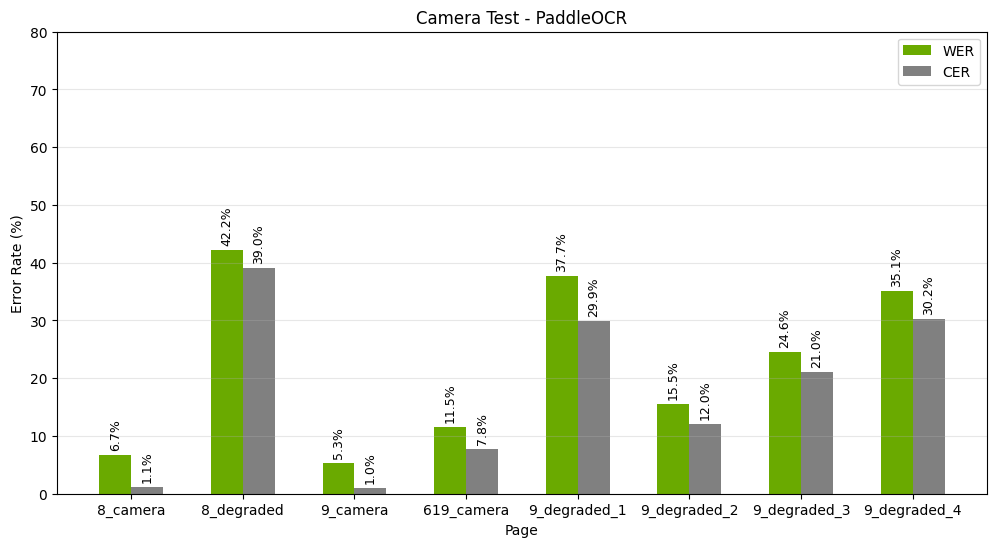

In [49]:
# With vector graphics
import numpy as np
import matplotlib.pyplot as plt
import os

# Reduce spacing between page groups
x = np.arange(len(df_exp1)) * 0.7

# Width of individual bars
width = 0.20

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(12, 6))

# WER bars
bars1 = plt.bar(
    x - width/2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

# CER bars
bars2 = plt.bar(
    x + width/2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

# WER values
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

# CER values
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_exp1["page"])

plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Camera Test - PaddleOCR")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 10))

os.makedirs(output_dir_2, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_2,
        "experiment_1_wer_cer_by_page_camera.pdf"
    ),
    bbox_inches="tight"
)

plt.show()